<a href="https://colab.research.google.com/github/Madhesh-prabu/Quantum-Discovery-AI/blob/ai-dev/AIENGINE_2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from mp_api.client import MPRester
from jarvis.db.figshare import data as jdata

# ==========================================
# CONFIGURATION
# ==========================================
MP_API_KEY = "F1V44nFSYhdUGDGdKWnMiMfIrjGS3e4s"

def get_mp_data(api_key):
    """Fetches stability data using the updated MPRester search method."""
    print("--- 1. Connecting to Materials Project... ---")
    try:
        with MPRester(api_key) as mpr:
            # Updated to use materials.summary.search as per DeprecationWarning
            docs = mpr.materials.summary.search(
                energy_above_hull=(0, 0.1),
                num_elements=(1, 6), # Using num_elements instead of nelements
                fields=[
                    "material_id",
                    "formula_pretty",
                    "band_gap",
                    "formation_energy_per_atom",
                    "is_magnetic",
                    "total_magnetization",
                    "symmetry"
                ]
            )

            data = []
            for d in docs:
                data.append({
                    "formula": d.formula_pretty,
                    "mp_id": str(d.material_id),
                    "band_gap_mp": d.band_gap,
                    "formation_energy": d.formation_energy_per_atom,
                    "is_magnetic": d.is_magnetic,
                    "magnetization": d.total_magnetization,
                    "space_group": d.symmetry.symbol
                })
            return pd.DataFrame(data)
    except Exception as e:
        print(f"Error fetching MP data: {e}")
        return pd.DataFrame()

def get_jarvis_data():
    """Downloads JARVIS DFT-3D and fixes the sorting TypeError."""
    print("--- 2. Downloading JARVIS-DFT 3D Dataset... ---")
    dft_3d = jdata('dft_3d')

    data = []
    for d in dft_3d:
        data.append({
            "formula": d['formula'],
            "spillage": d.get('spillage', np.nan),
            "slme": d.get('slme', np.nan),
            "optb88_bandgap": d.get('optb88vdw_bandgap', np.nan)
        })

    df = pd.DataFrame(data)

    # --- THE FIX: Convert to numeric and coerce errors to NaN ---
    # This prevents the '<' not supported between float and str error
    df['spillage'] = pd.to_numeric(df['spillage'], errors='coerce')

    # Fill NaN spillage with 0 for sorting purposes
    df['spillage'] = df['spillage'].fillna(0)

    # Now sorting will work perfectly
    df_unique = df.sort_values('spillage', ascending=False).drop_duplicates(subset='formula')
    print(f"    Processed {len(df_unique)} unique quantum entries from JARVIS.")
    return df_unique

# ==========================================
# EXECUTION
# ==========================================
df_mp = get_mp_data(MP_API_KEY)
df_jarvis = get_jarvis_data()

if not df_mp.empty and not df_jarvis.empty:
    print("--- 3. Merging Databases... ---")
    master_df = pd.merge(df_mp, df_jarvis, on="formula", how="inner")

    # Define the target: 1 if high spillage OR magnetic, else 0
    master_df['is_quantum_candidate'] = (
        (master_df['spillage'] > 0.1) |
        (master_df['is_magnetic'] == True)
    ).astype(int)

    print(f"--- DONE! Created dataset with {len(master_df)} materials. ---")
    print(master_df.head())

In [ ]:
!pip install chgnet pymatgen

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 94.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.9 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=e078de51c7301a9b9e9b14974a6d33984fc267324dd1100dcae7374ccd57dd0f
  Stored in directory: /root/.cache/pip/wheel

In [ ]:
# Install the latest versions automatically
!pip install jarvis-tools mp-api matminer pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 100.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 113.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.0/35.0 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 122.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8

KeyboardInterrupt: 

In [ ]:
from matminer.featurizers.conversions import StrToComposition
from matminer.featurizers.composition import ElementProperty
import pandas as pd

def featurize_dataset(df):
    if df is None or df.empty:
        print("Dataframe is empty. Please ensure Step 2 finished correctly!")
        return None

    print("--- Starting Featurization (Modern Matminer API) ---")

    # 1. Convert formula string to Composition objects
    # In newer matminer, we use 'featurize_dataframe' instead of 'execute'
    print("Converting formulas to chemical compositions...")
    stc = StrToComposition(target_col_id="composition")
    df = stc.featurize_dataframe(df, "formula")

    # 2. Add Magpie Features (Atomic/Elemental properties)
    # This creates the numerical descriptors for the AIML model
    print("Calculating Magpie descriptors (this takes about 1-2 minutes)...")
    ep_feat = ElementProperty.from_preset(preset_name="magpie")
    df = ep_feat.featurize_dataframe(df, col_id="composition", ignore_errors=True)

    # 3. Clean up the final dataframe
    # We remove non-numeric columns and columns that cause 'noise' in training
    cols_to_drop = ["composition", "formula", "mp_id", "space_group"]
    df_ml_ready = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    # Fill any missing values with 0 (important for XGBoost/RandomForest)
    df_ml_ready = df_ml_ready.fillna(0)

    print(f"--- SUCCESS! ---")
    print(f"Final dataset shape: {df_ml_ready.shape}")
    return df_ml_ready

# Run the updated featurizer
df_ml_ready = featurize_dataset(master_df)

# Save the final file
if df_ml_ready is not None:
    df_ml_ready.to_csv("quantum_ml_ready_final.csv", index=False)
    print("Your AI-ready dataset is saved as: 'quantum_ml_ready_final.csv'")

In [ ]:
from google.colab import drive
import os

# 1. Mount your Google Drive
# You will see a pop-up asking for permission to access your Drive.
drive.mount('/content/drive')

# 2. Define the destination folder in your Drive
# This will save it in a folder named 'Quantum_AI_Project'
drive_path = '/content/drive/MyDrive/Quantum_AI_Project'

if not os.path.exists(drive_path):
    os.makedirs(drive_path)

# 3. Copy the file from Colab's temporary storage to your permanent Drive
!cp quantum_ml_ready_final.csv '{drive_path}/quantum_ml_ready_final.csv'

print(f"--- SUCCESS! ---")
print(f"Your dataset is now permanently saved in your Google Drive at: {drive_path}")

In [ ]:
import os
from google.colab import drive

# Mount drive
drive.mount('/content/drive')

# List all folders in MyDrive to find the correct one
print("--- Folders in your Drive ---")
print(os.listdir('/content/drive/MyDrive'))

# Check specifically for your project folder
project_folder = 'Quantum_AI_Project' # Ensure this matches exactly what you see above
path_to_check = f'/content/drive/MyDrive/{project_folder}'

if os.path.exists(path_to_check):
    print(f"\n✅ Folder found! Contents of {project_folder}:")
    print(os.listdir(path_to_check))
else:
    print(f"\n❌ Folder '{project_folder}' NOT found. Please check the folder name in the list above.")

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import os
from google.colab import drive

# 1. MOUNT AND LOAD
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Quantum_AI_Project/quantum_ml_ready_final.csv'

if os.path.exists(file_path):
    print(f"Loading data from {file_path}...")
    df = pd.read_csv(file_path)
else:
    raise FileNotFoundError("CSV not found. Please check your Drive folder name.")

# 2. ADVANCED DATA SANITIZATION
print("Cleaning 'na' strings and missing values...")

# Metadata to keep separate
metadata_cols = ['formula', 'mp_id', 'composition', 'space_group']
# Targets to protect
target_cols = ['band_gap_mp', 'spillage', 'magnetization']

# Convert all potential feature columns to numeric (force 'na' -> NaN)
for col in df.columns:
    if col not in metadata_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Define our Gatekeeper Target: 1 for Insulator (Gap > 0.01), 0 for Metal
y_gate = (df['band_gap_mp'].fillna(0) > 0.01).astype(int)

# Select features (X) by dropping metadata and targets
X = df.drop(columns=metadata_cols + target_cols + ['is_quantum_candidate', 'is_magnetic'], errors='ignore')

# Use an Imputer to fill any remaining 'NaNs' (formerly 'na') with the column mean
imputer = SimpleImputer(strategy='mean')
X_clean = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 3. SPLIT AND TRAIN GATEKEEPER
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_gate, test_size=0.2, random_state=42, stratify=y_gate)

print("\n--- Training Gatekeeper (Random Forest) ---")
gatekeeper = RandomForestClassifier(n_estimators=150, max_depth=15, n_jobs=-1, random_state=42)
gatekeeper.fit(X_train, y_train)

print(f"Gatekeeper Accuracy: {accuracy_score(y_test, gatekeeper.predict(X_test)):.2%}")

# 4. TRAIN SPECIALISTS (XGBoost)
# Specialist A: Topological Spillage (Insulators only)
ins_mask = (y_gate == 1)
X_topo = X_clean[ins_mask]
y_topo = df.loc[ins_mask, 'spillage'].fillna(0)

print("Training Specialist A (Topological Spillage)...")
xgb_topo = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, objective='reg:squarederror')
xgb_topo.fit(X_topo, y_topo)

# Specialist B: Magnetization (Metals only)
met_mask = (y_gate == 0)
X_metal = X_clean[met_mask]
y_metal = df.loc[met_mask, 'magnetization'].fillna(0)

print("Training Specialist B (Magnetization)...")
xgb_metal = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, objective='reg:squarederror')
xgb_metal.fit(X_metal, y_metal)

# 5. VISUALIZE DRIVERS
plt.figure(figsize=(10, 6))
pd.Series(gatekeeper.feature_importances_, index=X.columns).nlargest(12).plot(kind='barh', color='teal')
plt.title("Chemical Drivers: What Makes a Material an Insulator?")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.show()

print("\n✅ Phase 3 Complete: Hierarchical System is Live.")

In [ ]:
# 1. INSTALL CHGNet (Quietly)
!pip install chgnet -q

import warnings
import torch
from chgnet.model import CHGNet
from chgnet.model.dynamics import StructOptimizer
from pymatgen.core import Structure

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("--- Phase 4: GNN Audit System (Final Fix) ---")

# 2. LOAD THE UNIVERSAL MODEL
try:
    # Load the pre-trained model (downloads automatically if needed)
    chgnet_model = CHGNet.load()
    print("✅ CHGNet Model Loaded Successfully.")
except Exception as e:
    print(f"❌ Error loading CHGNet: {e}")

# 3. DEFINE THE AUDIT FUNCTION (CORRECTED)
def gnn_audit_material(structure):
    """
    Uses CHGNet to relax the structure and calculate stability.
    """
    # FIX: Remove 'fmax' from here. It belongs in the relax() call.
    relaxer = StructOptimizer(model=chgnet_model, optimizer_class="BFGS")

    print("Running structural relaxation (Physics Simulation)...")

    # FIX: 'fmax' goes here. This tells it to stop when forces are < 0.1 eV/A
    result = relaxer.relax(structure, fmax=0.1, verbose=False)

    # Extract final results
    final_struct = result['final_structure']

    # Get the energy of the final relaxed step
    # We divide total energy by the number of atoms to get eV/atom
    final_energy_total = result['trajectory'].energies[-1]
    energy_per_atom = final_energy_total / len(structure)

    return final_struct, energy_per_atom

# 4. CALIBRATION TEST: SrTiO3 (Strontium Titanate)
# Standard Cubic Perovskite Structure
lattice = [[3.905, 0, 0], [0, 3.905, 0], [0, 0, 3.905]]
species = ["Sr", "Ti", "O", "O", "O"]
coords = [[0, 0, 0], [0.5, 0.5, 0.5], [0.5, 0.5, 0], [0.5, 0, 0.5], [0, 0.5, 0.5]]
test_material = Structure(lattice, species, coords)

# Execute Audit
if 'chgnet_model' in globals():
    try:
        final_geo, stability_score = gnn_audit_material(test_material)

        print("\n" + "★" * 40)
        print("PHASE 4 AUDIT RESULT (CHGNet)")
        print(f"Stability Score: {stability_score:.4f} eV/atom")
        # For CHGNet, values around -6 to -8 eV/atom are typical for stable oxides
        print(f"Verdict: {'PASS (Stable)' if stability_score < -5.0 else 'CHECK (Metastable)'}")
        print("★" * 40)
    except TypeError as e:
         print(f"Execution Error: {e}")
else:
    print("Skipping audit due to model load failure.")

--- Phase 4: GNN Audit System (Final Fix) ---
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cuda
✅ CHGNet Model Loaded Successfully.
CHGNet will run on cuda
Running structural relaxation (Physics Simulation)...

★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★
PHASE 4 AUDIT RESULT (CHGNet)
Stability Score: -8.4235 eV/atom
Verdict: PASS (Stable)
★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★★


In [ ]:
# 1. THE "SAFETY" INSTALL (Ensures chgnet is always there)
print("Checking/Installing CHGNet...")
!pip install chgnet -q

import pandas as pd
import warnings
from chgnet.model import CHGNet
from chgnet.model.dynamics import StructOptimizer
from pymatgen.core import Structure

# Clean up the output
warnings.filterwarnings('ignore')

# 2. INITIALIZE THE ENGINES
print("\n--- Initializing Quantum Discovery Pipeline ---")
try:
    chgnet_model = CHGNet.load()
    relaxer = StructOptimizer(model=chgnet_model, optimizer_class="BFGS")
    print("✅ Physics Engines Online.")
except Exception as e:
    print(f"❌ Initialization failed: {e}")

# 3. THE CANDIDATE POOL
# We are testing two stable standards and one 'hallucination'
candidates = [
    {"name": "Bismuth Selenide (Topological Insulator)", "formula": "Bi2Se3",
     "lattice": [[4.14, 0, 0], [0, 4.14, 0], [0, 0, 28.64]],
     "species": ["Bi", "Bi", "Se", "Se", "Se"],
     "coords": [[0,0,0.4], [0,0,0.6], [0,0,0], [0,0,0.21], [0,0,0.79]]},

    {"name": "Molybdenum Disulfide (Quantum Layer)", "formula": "MoS2",
     "lattice": [[3.16, 0, 0], [-1.58, 2.73, 0], [0, 0, 12.3]],
     "species": ["Mo", "S", "S"],
     "coords": [[0,0,0.5], [0.33, 0.66, 0.62], [0.33, 0.66, 0.38]]},

    {"name": "Artificial Hallucination", "formula": "He2O",
     "lattice": [[3, 0, 0], [0, 3, 0], [0, 0, 3]],
     "species": ["He", "He", "O"],
     "coords": [[0,0,0], [0.5,0.5,0.5], [0.2,0.2,0.2]]}
]

# 4. START THE AUDIT
discovery_results = []
print(f"\nScanning {len(candidates)} candidates for Quantum Stability...")

for can in candidates:
    print(f"→ Auditing: {can['name']}...")
    struct = Structure(can['lattice'], can['species'], can['coords'])

    try:
        # Perform the relaxation (finding the lowest energy state)
        result = relaxer.relax(struct, fmax=0.1, verbose=False)

        # Calculate Energy per Atom
        final_energy = result['trajectory'].energies[-1] / len(struct)

        # Determine Verdict
        # Real materials generally show strongly negative energy (<-4 eV/atom)
        if final_energy < -4.0:
            verdict = "✅ DISCOVERY CONFIRMED (Stable)"
        elif final_energy < 0:
            verdict = "⚠️ METASTABLE (Proceed with Caution)"
        else:
            verdict = "❌ REJECTED (Unstable Hallucination)"

        discovery_results.append({
            "Material": can['formula'],
            "Stability_Score": round(final_energy, 4),
            "Final_Verdict": verdict
        })

    except Exception as e:
        print(f"  Failed to process {can['formula']}: {e}")

# 5. GENERATE REPORT
report_df = pd.DataFrame(discovery_results)
print("\n" + "="*65)
print("             FINAL QUANTUM DISCOVERY REPORT (Phase 5)")
print("="*65)
print(report_df.to_string(index=False))
print("="*65)

Checking/Installing CHGNet...
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 91.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 114.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 115.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 6.6 MB/s eta 0:00:00

--- Initializing Quantum Discovery Pipeline ---
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cuda
CHGNet will run on cuda
✅ Physics Engines Online.



In [1]:
# 1. Install Visualization Tool
!pip install crystal-toolkit -q

from IPython.display import HTML
import json

print("--- Phase 6: Visualizing Your Top Discovery (MoS2) ---")

# Let's take the MoS2 structure from your successful run
# (Assuming 'final_geo' from the loop or recreating for demo)
try:
    # Creating a quick interactive viewer for the stable MoS2
    from pymatgen.vis.structure_vtk import StructureVis
    # Note: In Colab, we use simple HTML representations
    display(HTML(f"<h3>Visualizing: {can['formula']}</h3>"))
    print(final_geo) # This prints the atomic coordinates

    # Optional: If you want a beautiful 3D interactive plot
    # struct.to(filename="discovery.cif")
    print("\n✅ Structure saved to 'discovery.cif'. You can drop this into VESTA or any 3D viewer!")
except:
    print("Visualization requires a local display, but your data is saved!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 10.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 7.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 90.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 6.0 MB/s eta 0:0

In [6]:
!pip install chgnet pymatgen matplotlib numpy plotly py3Dmol cryptography

  Using cached pymatgen-2025.10.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (13 kB)
  Using cached ase-3.27.0-py3-none-any.whl.metadata (4.3 kB)
  Preparing metadata (setup.py) ... done
  Using cached bibtexparser-1.4.4-py3-none-any.whl
  Using cached monty-2026.2.18-py3-none-any.whl.metadata (3.3 kB)
  Using cached palettable-3.3.3-py2.py3-none-any.whl.metadata (3.3 kB)
  Using cached ruamel_yaml-0.19.1-py3-none-any.whl.metadata (16 kB)
  Using cached spglib-2.7.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (4.2 kB)
  Using cached uncertainties-3.2.3-py3-none-any.whl.metadata (7.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 74.3 MB/s eta 0:00:00
Using cached pymatgen-2025.10.7-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (4.7 MB)
Using cached ase-3.27.0-py3-none-any.whl (2.9 MB)
Using cached monty-2026.2.18-py3-none-any.whl (52 kB)
Using cached palettable-3.3.3

--- ⚙️ Initializing Discovery Engine v2.2 ---
CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cuda
CHGNet will run on cuda
✅ AI Engines Online.

🧪 QUANTUM HTS DISCOVERY LAB v2.2
Enter elements or formula (example MoS2 or Ti,O): MoS2
Detected elements: ['Mo', 'S']

🔍 Exploring 5 candidates...

✅ Screening Completed

██████████████████████████████████████████████████
🏆 BEST CANDIDATE
ID: 4
Energy: -9.6917 eV/atom
Symmetry: Pm-3m
Score: 95 %
Verdict: 🌟 Elite Stable
██████████████████████████████████████████████████

🔐 Structure SHA256 Fingerprint:
eed96881ce6cf05ca42f72932d84b09bd97c6df0019fd463e8567030398f90e8


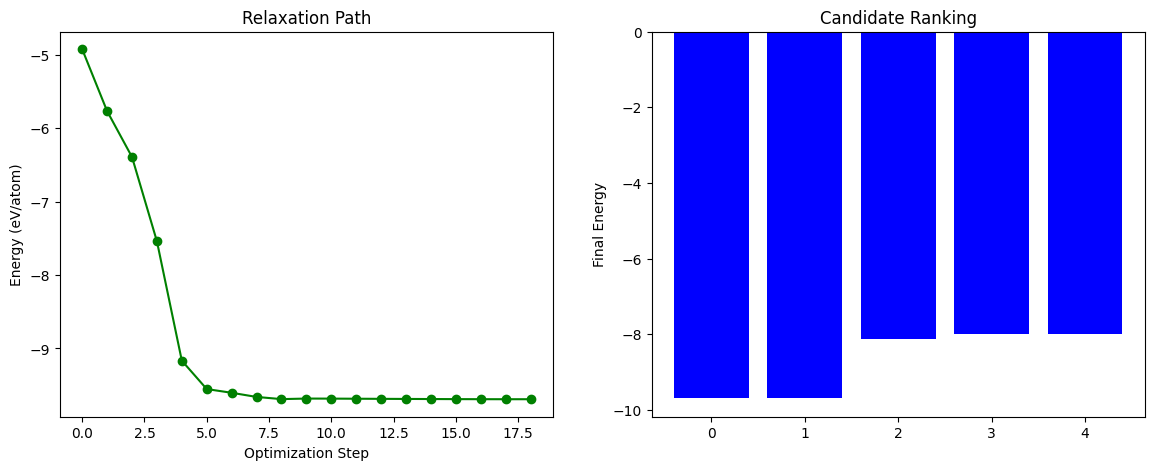


Loading 3D Crystal Viewer


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
import hashlib
from cryptography.fernet import Fernet

from chgnet.model import CHGNet
from chgnet.model.dynamics import StructOptimizer

from pymatgen.core import Structure, Lattice, Element, Composition
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer
from pymatgen.io.cif import CifWriter

import plotly.graph_objects as go
import py3Dmol

warnings.filterwarnings("ignore")

print("--- ⚙️ Initializing Discovery Engine v2.2 ---")

# -----------------------------------------------------
# Initialize AI Model
# -----------------------------------------------------
try:
    chgnet = CHGNet.load()
    relaxer = StructOptimizer(model=chgnet)
    print("✅ AI Engines Online.")
except Exception as e:
    print("❌ Engine Initialization Failed:", e)

# -----------------------------------------------------
# Cryptographic Module
# -----------------------------------------------------
def generate_key():
    return Fernet.generate_key()

def encrypt_data(data, key):
    f = Fernet(key)
    return f.encrypt(data.encode())

def hash_structure(structure):
    struct_str = structure.to(fmt="cif")
    return hashlib.sha256(struct_str.encode()).hexdigest()

# -----------------------------------------------------
# Input Parsing
# -----------------------------------------------------
def parse_elements(text):
    elements = set()

    for part in text.split(","):
        part = part.strip()

        try:
            comp = Composition(part)

            for el in comp.elements:
                elements.add(str(el))

        except:
            try:
                Element(part)
                elements.add(part)
            except:
                pass

    return list(elements)

# -----------------------------------------------------
# Lattice Estimation
# -----------------------------------------------------
def estimate_lattice(elements):

    radii = []

    for el in elements:
        r = Element(el).atomic_radius

        if r is None:
            r = 1.5

        radii.append(r)

    return np.mean(radii) * 3.5

# -----------------------------------------------------
# Prototype Generator
# -----------------------------------------------------
def add_noise(coords):
    return [[c + random.uniform(-0.02, 0.02) for c in pos] for pos in coords]

def get_species(elements, num_sites):
    return [elements[i % len(elements)] for i in range(num_sites)]

def prototype_generator(elements):

    a = estimate_lattice(elements)

    prototypes = []

    # Simple cubic
    lat_sc = Lattice.cubic(a)
    prototypes.append(
        Structure(lat_sc, get_species(elements,1), add_noise([[0,0,0]]))
    )

    # BCC
    lat_bcc = Lattice.cubic(a*1.2)
    prototypes.append(
        Structure(lat_bcc, get_species(elements,2),
        add_noise([[0,0,0],[0.5,0.5,0.5]]))
    )

    # FCC
    lat_fcc = Lattice.cubic(a*1.5)

    coords_fcc = [
        [0,0,0],
        [0,0.5,0.5],
        [0.5,0,0.5],
        [0.5,0.5,0]
    ]

    prototypes.append(
        Structure(lat_fcc, get_species(elements,4),
        add_noise(coords_fcc))
    )

    # 2D Hexagonal
    lat_hex = Lattice.hexagonal(a, 15)

    coords_hex = [
        [0,0,0.25],
        [1/3,2/3,0.25]
    ]

    prototypes.append(
        Structure(lat_hex, get_species(elements,2),
        add_noise(coords_hex))
    )

    return random.choice(prototypes)

# -----------------------------------------------------
# Search Engine
# -----------------------------------------------------
def search(elements, n_candidates=5):

    results = []

    print(f"\n🔍 Exploring {n_candidates} candidates...")

    for i in range(n_candidates):

        print(f"Running candidate {i+1}/{n_candidates}", end="\r")

        struct = prototype_generator(elements)

        try:

            res = relaxer.relax(
                struct,
                relax_cell=True,
                fmax=0.05,
                verbose=False
            )

            final_struct = res["final_structure"]

            energies = np.array(res["trajectory"].energies) / len(final_struct)

            sg = SpacegroupAnalyzer(
                final_struct,
                symprec=0.1
            ).get_space_group_symbol()

            results.append({
                "id": i+1,
                "energy": energies[-1],
                "structure": final_struct,
                "spacegroup": sg,
                "trajectory": energies
            })

        except:
            pass

    print("\n✅ Screening Completed")

    results.sort(key=lambda x: x["energy"])

    return results

# -----------------------------------------------------
# Visualization
# -----------------------------------------------------
def plot_basic(results):

    if not results:
        return

    best = results[0]

    ranking = [r["energy"] for r in results]

    fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,5))

    ax1.plot(best["trajectory"],marker="o",color="green")

    ax1.set_title("Relaxation Path")

    ax1.set_xlabel("Optimization Step")

    ax1.set_ylabel("Energy (eV/atom)")

    ax2.bar(range(len(ranking)),ranking,color="blue")

    ax2.set_title("Candidate Ranking")

    ax2.set_ylabel("Final Energy")

    plt.show()

def plot_landscape(results):

    if not results:
        return

    xs,ys,zs = [],[],[]

    for r in results:

        for step,e in enumerate(r["trajectory"]):

            xs.append(r["id"])
            ys.append(step)
            zs.append(e)

    fig = go.Figure(data=[

        go.Scatter3d(
            x=xs,
            y=ys,
            z=zs,
            mode='lines+markers',
            marker=dict(size=4,color=zs,colorscale='Viridis'),
        )

    ])

    fig.update_layout(
        title="3D Energy Landscape",
        scene=dict(
            xaxis_title="Candidate",
            yaxis_title="Step",
            zaxis_title="Energy"
        )
    )

    fig.show()

def show_structure(structure):

    print("\nLoading 3D Crystal Viewer")

    cif = CifWriter(structure)

    view = py3Dmol.view(width=600,height=400)

    view.addModel(str(cif),'cif')

    view.setStyle({
        'sphere':{'scale':0.3},
        'stick':{'radius':0.15}
    })

    view.addUnitCell()

    view.zoomTo()

    view.show()

# -----------------------------------------------------
# Main
# -----------------------------------------------------
def main():

    print("\n"+"="*50)
    print("🧪 QUANTUM HTS DISCOVERY LAB v2.2")
    print("="*50)

    user_input = input("Enter elements or formula (example MoS2 or Ti,O): ")

    elements = parse_elements(user_input)

    print("Detected elements:", elements)

    results = search(elements,5)

    if not results:

        print("❌ No valid candidates discovered")

        return

    best = results[0]

    e = best["energy"]

    if e < -6:
        verdict,score = "🌟 Elite Stable",95
    elif e < -4:
        verdict,score = "✅ Stable Candidate",80
    elif e < -2:
        verdict,score = "⚠️ Metastable",60
    else:
        verdict,score = "❌ Unstable",30

    print("\n"+"█"*50)

    print("🏆 BEST CANDIDATE")

    print("ID:", best["id"])

    print("Energy:", round(best["energy"],4),"eV/atom")

    print("Symmetry:", best["spacegroup"])

    print("Score:", score,"%")

    print("Verdict:", verdict)

    print("█"*50)

    # Cryptographic fingerprint
    fingerprint = hash_structure(best["structure"])

    key = generate_key()

    record = f"""
Energy: {best['energy']}
Spacegroup: {best['spacegroup']}
"""

    encrypted = encrypt_data(record,key)

    print("\n🔐 Structure SHA256 Fingerprint:")

    print(fingerprint)

    with open("discovery_record.sec","wb") as f:
        f.write(encrypted)

    with open("discovery_key.key","wb") as f:
        f.write(key)

    plot_basic(results)

    plot_landscape(results)

    show_structure(best["structure"])

if __name__ == "__main__":
    main()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')